In [6]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install xlrd
df = pd.read_csv("hotel_bookings.csv")

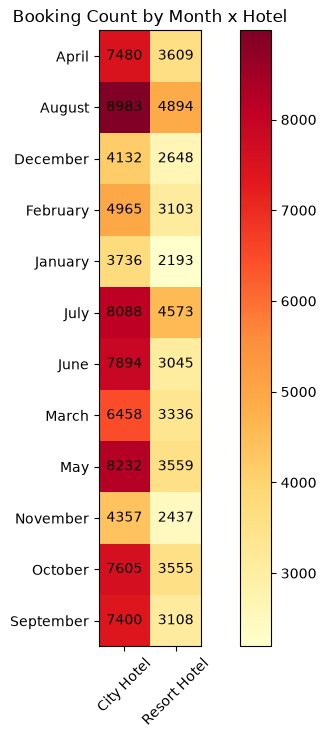

In [7]:
# How many reservations happened, in each hotel, per month

pivot_month_hotel = df.pivot_table(index =  "arrival_date_month",
 columns= "hotel",
 values="is_canceled",
 aggfunc = "count", observed=False)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot_month_hotel, cmap="YlOrRd")

ax.set_xticks(range(len(pivot_month_hotel.columns)))
ax.set_xticklabels(pivot_month_hotel.columns, rotation = 45)
ax.set_yticks(range(len(pivot_month_hotel.index)))
ax.set_yticklabels(pivot_month_hotel.index)

for i in range(len(pivot_month_hotel.index)):
    for j in range(len(pivot_month_hotel.columns)):
        ax.text(j, i, pivot_month_hotel.iloc[i, j], ha="center", va="center")

plt.colorbar(im)
plt.title("Booking Count by Month x Hotel")
plt.show()

                  

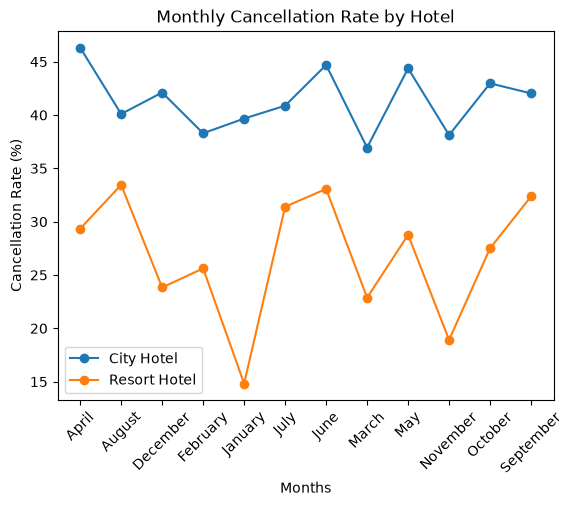

In [13]:
# Monthly Cancellation Rate

cancel_month_hotel = df.pivot_table(
    index="arrival_date_month",  
    columns="hotel",             
    values="is_canceled",      
    aggfunc="mean"           
) * 100

plt.figure()
plt.plot(cancel_month_hotel.index, cancel_month_hotel["City Hotel"], marker="o", label="City Hotel")
plt.plot(cancel_month_hotel.index, cancel_month_hotel["Resort Hotel"], marker="o", label="Resort Hotel")
plt.title("Monthly Cancellation Rate by Hotel")
plt.xlabel("Months")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()
           

In [15]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"].astype(str) + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

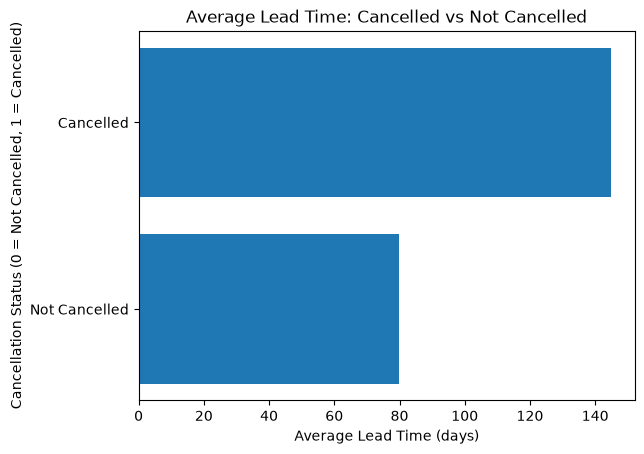

In [35]:
# Lead Time Comparison: Cancelled vs Not Cancelled
lead_time_compare = df.groupby("is_canceled")["lead_time"].mean()

lead_time_compare.index = ["Not Cancelled", "Cancelled"]
plt.barh(lead_time_compare.index, lead_time_compare.values)

plt.title("Average Lead Time: Cancelled vs Not Cancelled")
plt.xlabel("Average Lead Time (days)")
plt.ylabel("Cancellation Status (0 = Not Cancelled, 1 = Cancelled)")
plt.show()

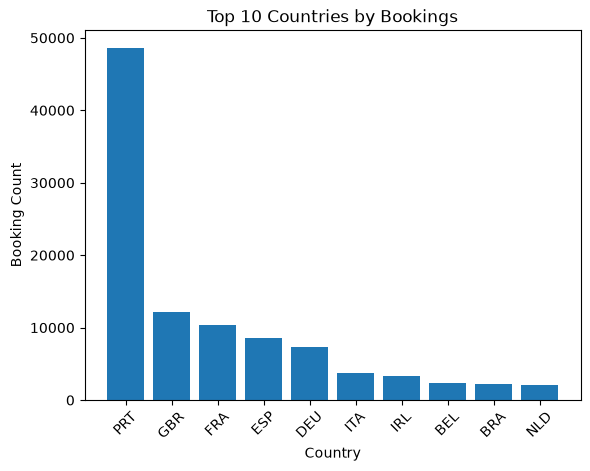

In [36]:
top10_countries = df["country"].value_counts(ascending = False).head(10)

plt.figure()
plt.bar(top10_countries.index, top10_countries.values)
plt.title("Top 10 Countries by Bookings")
plt.xlabel("Country")
plt.ylabel("Booking Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Top 10 Countries by Bookings
country_cancel_rate = df[df["country"].isin(top10_countries.index)].groupby("country")["is_canceled"].mean() * 100

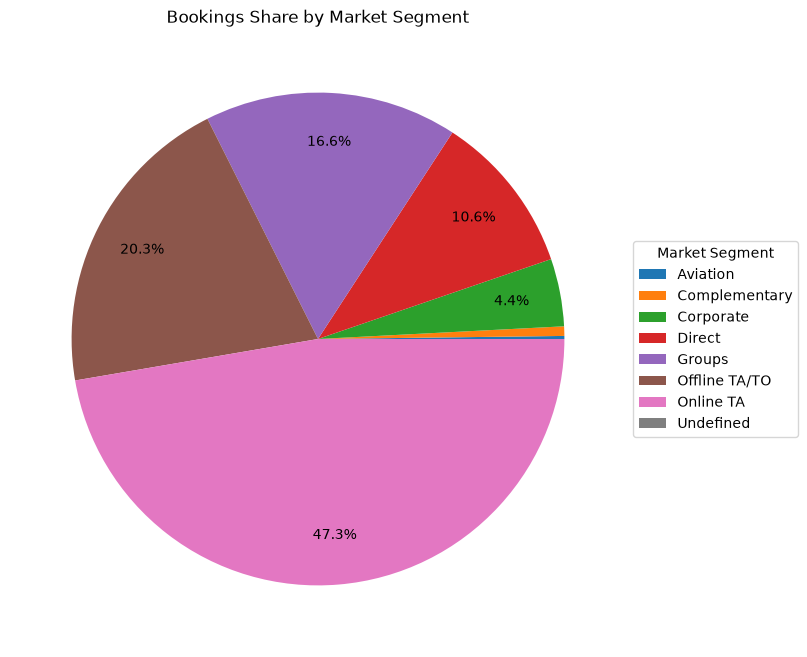

In [27]:
# Market Segment Breakdown
segment_summary = df.groupby("market_segment").agg(
    total_bookings=("is_canceled", "count"),
    cancellation_rate_pct=("is_canceled", "mean")
)
segment_summary["cancellation_rate_pct"] = segment_summary["cancellation_rate_pct"] * 100

plt.figure(figsize=(10, 8))

def show_pct(pct):
    return f"{pct:.1f}%" if pct >= 2 else ""

wedges, texts, autotexts = plt.pie(
    segment_summary["total_bookings"],
    autopct=show_pct,
    pctdistance=0.8
)
plt.legend(wedges, segment_summary.index, title="Market Segment", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Bookings Share by Market Segment")
plt.show()

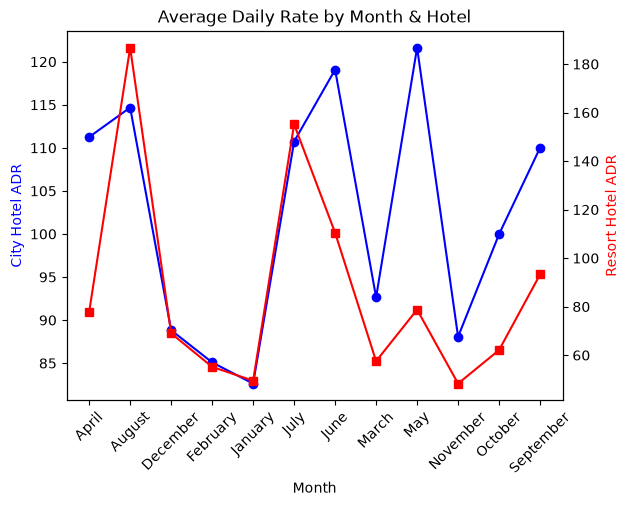

In [28]:
# Average Daily Rate by Month & Hotel

adr_month_hotel = df.pivot_table(
    index="arrival_date_month", 
    columns="hotel",            
    values="adr",               
    aggfunc="mean"               
)

fig, ax1 = plt.subplots()

ax1.plot(adr_month_hotel.index, adr_month_hotel["City Hotel"], color="blue", marker="o", label="City Hotel")
ax1.set_xlabel("Month")
ax1.set_ylabel("City Hotel ADR", color="blue")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(adr_month_hotel.index, adr_month_hotel["Resort Hotel"], color="red", marker="s", label="Resort Hotel")
ax2.set_ylabel("Resort Hotel ADR", color="red")

plt.title("Average Daily Rate by Month & Hotel")
plt.show()

In [29]:
segment_cancel_rate = df.groupby("market_segment")["is_canceled"].mean() * 100
segment_cancel_rate.sort_values(ascending=True).head(1)

market_segment
Complementary    13.055182
Name: is_canceled, dtype: float64

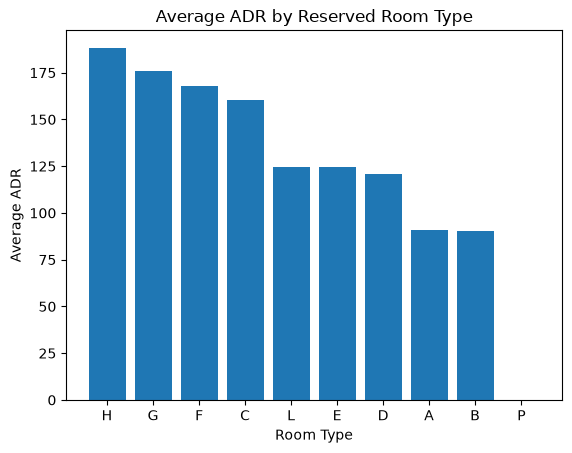

In [30]:
# Room Type Changes & Pricing Analysis

room_changed = df["reserved_room_type"] != df["assigned_room_type"]
room_changed.mean()*100
df[room_changed]["is_canceled"].mean() * 100
df[~room_changed]["is_canceled"].mean() * 100
adr_by_room = df.groupby("reserved_room_type")["adr"].mean().sort_values(ascending=False)
round(adr_by_room, 1)
plt.figure()
plt.bar(adr_by_room.index, adr_by_room.values)
plt.title("Average ADR by Reserved Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average ADR")
plt.show()